In [1]:
import numpy as np

def zoom_image(img, s, method='nearest'):
    h, w = img.shape[:2]
    new_h, new_w = int(h * s), int(w * s)

    zoomed = np.zeros((new_h, new_w, 3), dtype=np.uint8)

    for i in range(new_h):
        for j in range(new_w):

            # Map to original image
            x = i / s
            y = j / s

            if method == 'nearest':
                xi = min(int(round(x)), h-1)
                yj = min(int(round(y)), w-1)
                zoomed[i, j] = img[xi, yj]

            elif method == 'bilinear':
                x1, y1 = int(x), int(y)
                x2, y2 = min(x1+1, h-1), min(y1+1, w-1)

                dx = x - x1
                dy = y - y1

                zoomed[i, j] = (
                    (1-dx)*(1-dy)*img[x1,y1] +
                    dx*(1-dy)*img[x2,y1] +
                    (1-dx)*dy*img[x1,y2] +
                    dx*dy*img[x2,y2]
                )

    return zoomed.astype(np.uint8)



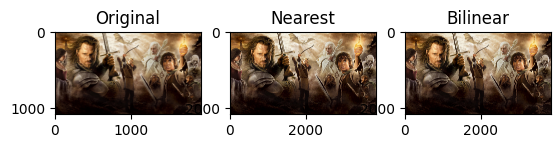

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('im01.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

nn = zoom_image(img, 2, 'nearest')
bilinear = zoom_image(img, 2, 'bilinear')

plt.subplot(1,3,1)
plt.imshow(img); plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(nn); plt.title("Nearest")

plt.subplot(1,3,3)
plt.imshow(bilinear); plt.title("Bilinear")

plt.show()

In [ ]:
# SSD Function
def compute_ssd(img1, img2):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    return np.sum((img1 - img2) ** 2) / img1.size

original = cv2.imread('im01.png')
small = cv2.imread('im01small.png')

if original is None or small is None:
    print("Error: Check image file paths!")
    exit()

# Convert for display
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
small_rgb = cv2.cvtColor(small, cv2.COLOR_BGR2RGB)

# Compute Scale Factor
s = original.shape[0] / small.shape[0]
print("Scale factor:", s)

#Apply Zoom
nn_img = zoom_image(small, s, 'nearest')
bilinear_img = zoom_image(small, s, 'bilinear')

# Ensure same size (safety)
nn_img = cv2.resize(nn_img, (original.shape[1], original.shape[0]))
bilinear_img = cv2.resize(bilinear_img, (original.shape[1], original.shape[0]))

#Compute SSD
ssd_nn = compute_ssd(original, nn_img)
ssd_bilinear = compute_ssd(original, bilinear_img)

print("SSD (Nearest Neighbor):", ssd_nn)
print("SSD (Bilinear):", ssd_bilinear)

Scale factor: 4.0
SSD (Nearest Neighbor): 255.29568
SSD (Bilinear): 200.24515


Bilinear interpolation gives better quality (lower SSD).


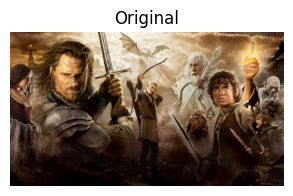

In [9]:
# Comparison
if ssd_bilinear < ssd_nn:
    print("Bilinear interpolation gives better quality (lower SSD).")
else:
    print("Nearest neighbor gives better quality.")

# Display Results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(original_rgb)
plt.title("Original")
plt.axis('off')

plt.show()

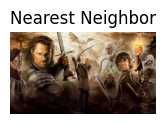

In [5]:
plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(nn_img, cv2.COLOR_BGR2RGB))
plt.title("Nearest Neighbor")
plt.axis('off')
plt.show()

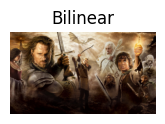

In [7]:
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(bilinear_img, cv2.COLOR_BGR2RGB))
plt.title("Bilinear")
plt.axis('off')
plt.show()